In [ ]:
%pip install scikit-learn pandas sentence-transformers seaborn nltk -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
FILENAME = "Customer_support_data.csv"

nltk.download("vader_lexicon")

### Первичный анализ данных и предобработка

In [20]:
df = pd.read_csv(FILENAME)

df.info()

display(df.describe())

display(df.describe(include="str"))

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,85907,85907,85907,85907,85907
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,1371,40,6,5,5
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,Wendy Taylor,Carter Park,John Smith,>90,Morning
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,429,4273,25261,30660,41426


In [21]:
print("Полных дубликатов строк:", df.duplicated().sum())
print(f"Строк с пропущенными значениями: \n{df.isna().sum()}")

Полных дубликатов строк: 0
Строк с пропущенными значениями: 
Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64



Распределение целевых классов: CSAT Score
5    69.40
1    13.07
4    13.06
3     2.98
2     1.49
Name: proportion, dtype: float64


<Axes: xlabel='CSAT Score', ylabel='count'>

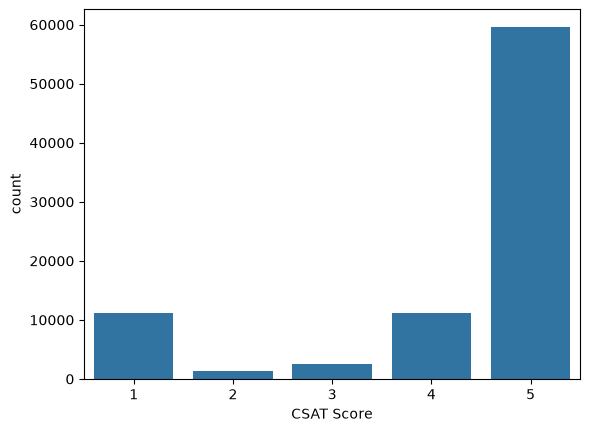

In [22]:
class_weights = df["CSAT Score"].value_counts(normalize=True).round(4)*100
print("\nРаспределение целевых классов:", class_weights)

sns.countplot(df, x="CSAT Score")

In [23]:
def missing_data_rate(col: pd.Series, total_rows: int) -> None:
    missing_col_rows = col.isna().sum()
    return round(missing_col_rows / total_rows, 2)

missing_threshold = 0.75
total_rows = df.shape[0]
for col in df.columns:
    col_missing_rate = missing_data_rate(df[col], total_rows)
    
    if col_missing_rate >= missing_threshold:
        print(
            f"У признака '{col}' пропущено значений больше порогового: "
            f"{col_missing_rate} vs {missing_threshold}."
            "Данный признак будет удален."
        )
        df.pop(col)

    elif col_missing_rate == 0:
        print(
            f"У признака '{col}' отсутствуют пропуски."
        )

    else:
        print(
            f"У признака '{col}' пропусков в данных {col_missing_rate * 100}%. "
            "Необходимо уделить внимание."
        )

У признака 'Unique id' отсутствуют пропуски.
У признака 'channel_name' отсутствуют пропуски.
У признака 'category' отсутствуют пропуски.
У признака 'Sub-category' отсутствуют пропуски.
У признака 'Customer Remarks' пропусков в данных 67.0%. Необходимо уделить внимание.
У признака 'Order_id' пропусков в данных 21.0%. Необходимо уделить внимание.
У признака 'order_date_time' пропущено значений больше порогового: 0.8 vs 0.75.Данный признак будет удален.
У признака 'Issue_reported at' отсутствуют пропуски.
У признака 'issue_responded' отсутствуют пропуски.
У признака 'Survey_response_Date' отсутствуют пропуски.
У признака 'Customer_City' пропущено значений больше порогового: 0.8 vs 0.75.Данный признак будет удален.
У признака 'Product_category' пропущено значений больше порогового: 0.8 vs 0.75.Данный признак будет удален.
У признака 'Item_price' пропущено значений больше порогового: 0.8 vs 0.75.Данный признак будет удален.
У признака 'connected_handling_time' пропущено значений больше поро

### Создание новых признаков, заполнение пропусков

In [24]:
df["has_remark"] = df["Customer Remarks"].isna().astype("int")

df["remark_len"] = df["Customer Remarks"].fillna("").apply(len)

Семантический анализ настроения отзыва пользователей

In [25]:
sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = (
    df["Customer Remarks"]
    .fillna("")
    .apply(lambda x: sia.polarity_scores(x)["compound"])
)

df["remarks_mood"] = (
    df["sentiment_score"]
    .apply(
        lambda x: "positive"
        if x > 0.05
        else ("negative" if x < -0.05 else "neutral")
    )
)

Создание признаков на основе timestamp

In [26]:
df[["issue_responded", "Issue_reported at", "Survey_response_Date"]].head(1)

,issue_responded,Issue_reported at,Survey_response_Date
0,01/08/2023 11:47,01/08/2023 11:13,01-Aug-23


In [27]:
df["issue_responded"] = pd.to_datetime(df["issue_responded"], dayfirst=True, errors="coerce")

df["Issue_reported at"] = pd.to_datetime(df["Issue_reported at"], dayfirst=True, errors="coerce")

df["issue_responce_time"] = (df["issue_responded"] - df["Issue_reported at"]).dt.total_seconds() / 60

In [28]:
incorrect_mask = df["issue_responce_time"] < 0

print(
    "Временные искажения, где на запрос ответили раньше, чем его создали: "
    f"{df["issue_responce_time"][incorrect_mask].count()}"
)

df["is_negative_response_time"] = (df["issue_responce_time"] < 0).astype(int)

df["issue_responce_time"] = (
    df
    .groupby("Agent_name")["issue_responce_time"]
    .transform(
        lambda x: np.where(x < 0, x.median(), x)
    )
)

Временные искажения, где на запрос ответили раньше, чем его создали: 3128


Применим частотное кодирование к агентам

In [29]:
agent_count = df["Agent_name"].value_counts().to_dict()

df["agent_freq"] = df["Agent_name"].map(agent_count)

Удалим неинформативные признаки и признаки времени-даты (пока без анализа временных рядов)

In [30]:
useless_cols = ["Unique id", "Order_id", "Agent_name", "Customer Remarks", "sentiment_score"]
timestamp_cols = ["Issue_reported at", "issue_responded", "Survey_response_Date"]

df = df.drop(columns=useless_cols + timestamp_cols)

In [31]:
str_cols = df.select_dtypes(include="str").columns.to_list()

df[str_cols] = df[str_cols].astype("category")

### Baseline задачи классификации

In [32]:
df.describe(include="all")

,channel_name,category,Sub-category,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,has_remark,remark_len,remarks_mood,issue_responce_time,is_negative_response_time,agent_freq
count,85907,85907,85907,85907,85907,85907,85907,85907.000000,85907.000000,85907.000000,85907,85907.000000,85907.000000,85907.000000
unique,3,12,57,40,6,5,5,NaN,NaN,NaN,3,NaN,NaN,NaN
top,Inbound,Returns,Reverse Pickup Enquiry,Carter Park,John Smith,>90,Morning,NaN,NaN,NaN,neutral,NaN,NaN,NaN
freq,68142,44097,22389,4273,25261,30660,41426,NaN,NaN,NaN,62160,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.242157,0.665429,14.515825,NaN,169.865500,0.036411,82.733433
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.378903,0.471843,49.204336,NaN,555.727367,0.187313,47.494745
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,0.000000,0.000000,20.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,0.000000,0.000000,NaN,2.000000,0.000000,53.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,1.000000,0.000000,NaN,6.000000,0.000000,75.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,1.000000,8.000000,NaN,35.000000,0.000000,102.000000


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   channel_name               85907 non-null  category
 1   category                   85907 non-null  category
 2   Sub-category               85907 non-null  category
 3   Supervisor                 85907 non-null  category
 4   Manager                    85907 non-null  category
 5   Tenure Bucket              85907 non-null  category
 6   Agent Shift                85907 non-null  category
 7   CSAT Score                 85907 non-null  int64   
 8   has_remark                 85907 non-null  int64   
 9   remark_len                 85907 non-null  int64   
 10  remarks_mood               85907 non-null  category
 11  issue_responce_time        85907 non-null  float64 
 12  is_negative_response_time  85907 non-null  int64   
 13  agent_freq                 85907 non-null 

In [34]:
X = df.drop(columns=["CSAT Score"])
y = df["CSAT Score"]

In [35]:
num_cols = ["issue_responce_time", "agent_freq", "remark_len"]

cat_cols = df.select_dtypes(include="category").columns.to_list()

std_pipe = Pipeline(steps=[
    ("std", StandardScaler()),
])

ohe_pipe = Pipeline(steps=[
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

preprocessing = ColumnTransformer(transformers=[
    ("num_cats", std_pipe, num_cols),
    ("ohe_cats", ohe_pipe, cat_cols),
])

In [36]:
clf = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("model", LogisticRegression(max_iter=1000, random_state=SEED)),
])

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

In [38]:
clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[1,2,3,4,5]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['channel_name','category','Sub-category',...,'issue_responce_time', 'is_negative_response_time','agent_freq']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_cats', ...), ('ohe_cats', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'

In [39]:
y_pred = clf.predict(X_test)

In [40]:
def get_accuracy_scores(y_test, y_pred):

    acc = accuracy_score(y_test, y_pred)
    print(f"Точность классификации: {acc:.2f}")

    f1_marco = f1_score(y_test, y_pred, average="macro")
    print(f"f1-score macro: {f1_marco:.2f}")

    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    print(f"f1-score weighted: {f1_weighted:.2f}")

get_accuracy_scores(y_test, y_pred)

Точность классификации: 0.71
f1-score macro: 0.24
f1-score weighted: 0.62


In [41]:
def get_feature_names_from_preprocessor(preprocessor, X_sample):
    """Универсальный способ получить имена признаков после трансформации"""
    feature_names = []
    
    for _, transformer, columns in preprocessor.transformers_:
        if hasattr(transformer, "get_feature_names_out"):
            feature_names.extend(transformer.get_feature_names_out(columns))
    
    return feature_names

preprocessor = clf.named_steps["preprocessing"]

feature_names = get_feature_names_from_preprocessor(preprocessor, X_train)
print(f"Всего признаков: {len(feature_names)}")

feature_weights = clf.named_steps["model"].coef_
print(f"Всего весов: {feature_weights.shape}")

Всего признаков: 133
Всего весов: (5, 133)


In [42]:
TOP_N_FEATURES = 10

data = []
for i, class_weights in enumerate(feature_weights):
    for j, weight in enumerate(class_weights):
        data.append({
            "class": f"class_{i+1}",
            "feature": feature_names[j],
            "weight": weight
        })

df_weights = pd.DataFrame(data)

df_weights_sorted = df_weights.sort_values(["class", "weight"], ascending=[True, False])
top_per_class = df_weights_sorted.groupby("class").head(TOP_N_FEATURES)

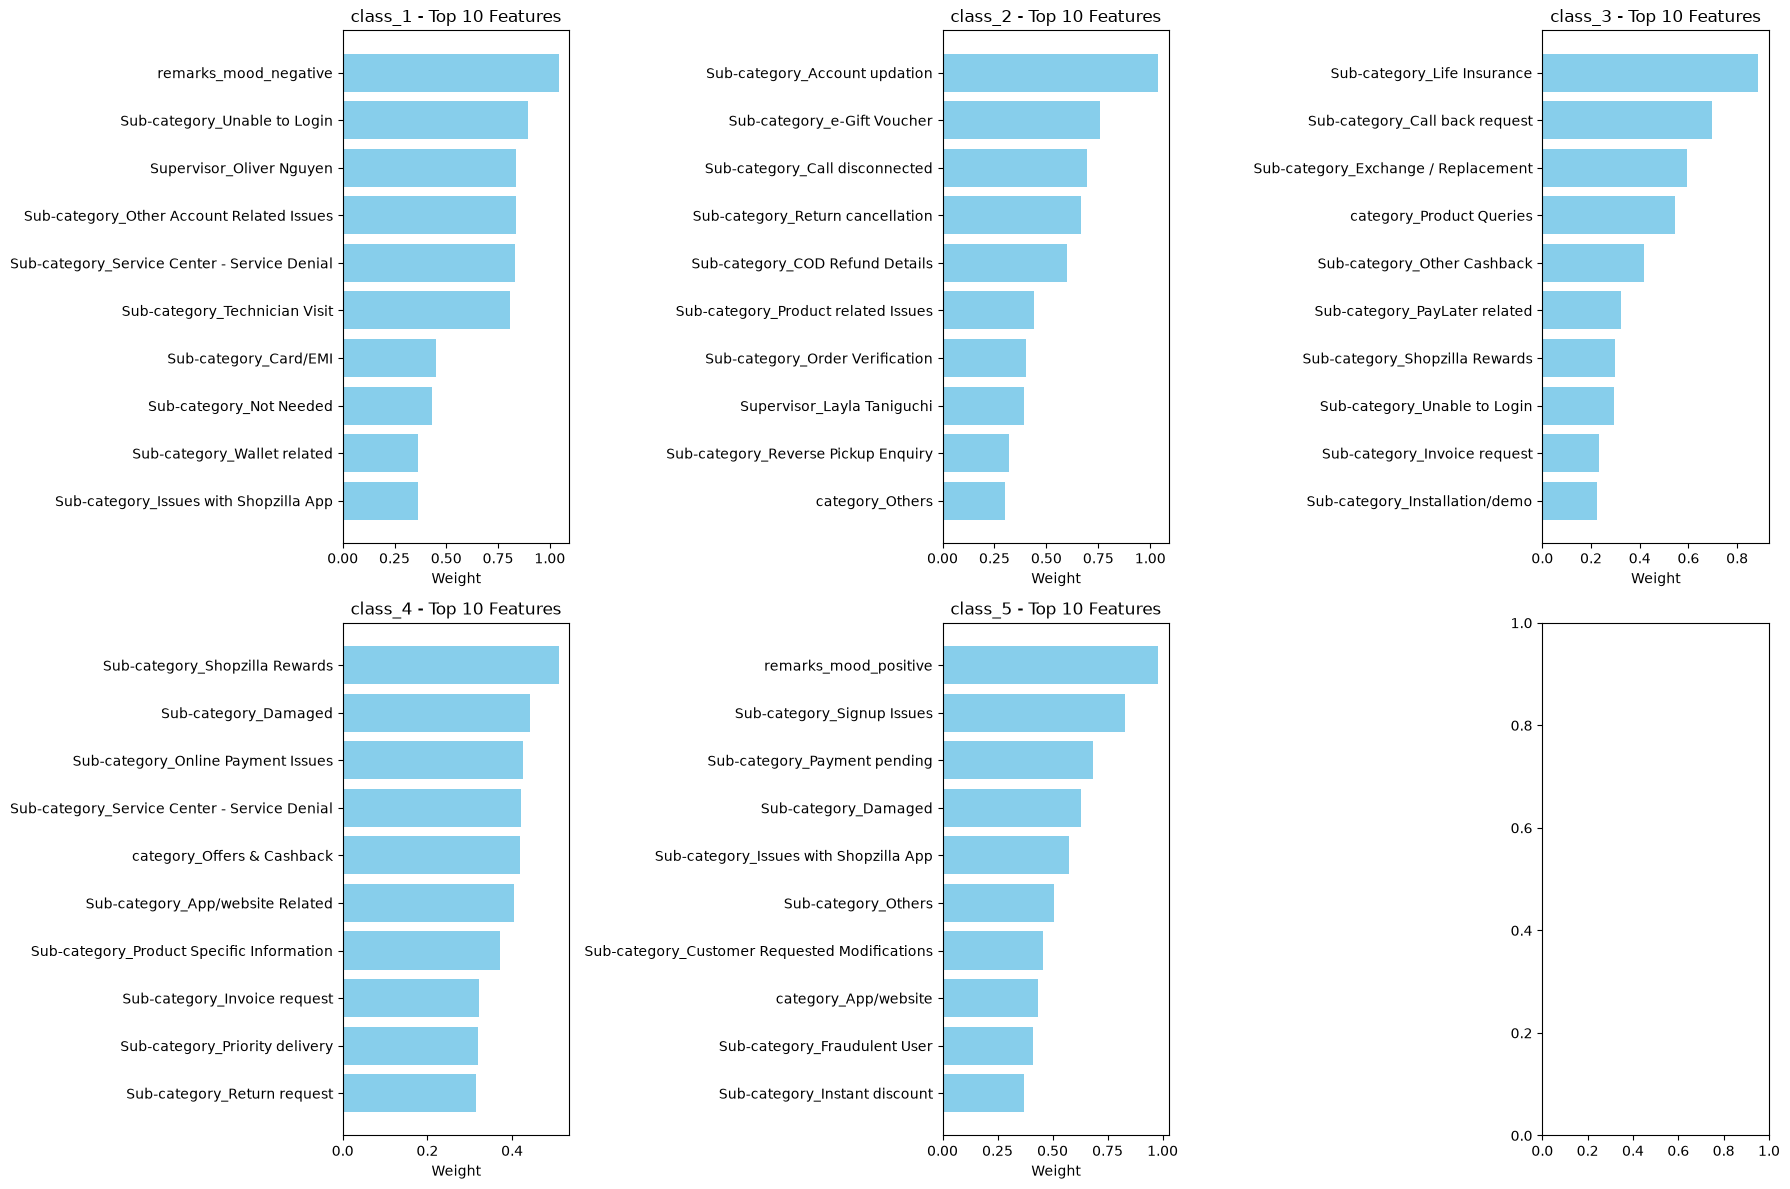

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, class_name in enumerate(top_per_class["class"].unique()):
    data = top_per_class[top_per_class["class"] == class_name]
    axes[i].barh(data["feature"], data["weight"], color="skyblue")
    axes[i].set_title(f"{class_name} - Top {TOP_N_FEATURES} Features", fontsize=12)
    axes[i].set_xlabel("Weight")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

### Улучшение baseline

Попытка улучшить модель многоклассовой логистической регрессии

In [ ]:
cv_clf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

clf = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("model", LogisticRegression(
        random_state=SEED,
        max_iter=2000,
    ))
])

clf_params = {
    "model__class_weight": [None, "balanced"],
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "saga"],
}

In [ ]:
grid_search = GridSearchCV(
    clf, clf_params,
    scoring="f1_macro",
    cv=cv_clf,
    n_jobs=-1,
    verbose=1,
)

In [ ]:
grid_search.fit(X_train, y_train)

best_cfl = grid_search.best_estimator_

In [ ]:
print(
    f"Лучшие параметры: {grid_search.best_params_}\n"
    f"Лучший показатель качества: {grid_search.best_score_:.2f}"
)

In [ ]:
best_y_pred = best_cfl.predict(X_test)

get_accuracy_scores(y_test, best_y_pred)

In [ ]:
print(classification_report(y_test, best_y_pred, zero_division=0))

Пробудем заменить простую модель на ансамбль из деревьев

In [ ]:
clf_rf = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("model", RandomForestClassifier(
        random_state=SEED,
        class_weight="balanced_subsample",
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        n_jobs=-1
    ))
])

clf_params_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [5, 10, 20],
    "model__class_weight": ["balanced", "balanced_subsample"],
}

cv_clf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED,
)

grid_search = GridSearchCV(
    clf_rf, clf_params_rf,
    scoring="f1_macro",
    cv=cv_clf,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train[:10000], y_train[:10000])

best_cfl = grid_search.best_estimator_

best_y_pred = best_cfl.predict(X_test)

print(classification_report(y_test, best_y_pred, zero_division=0))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Точность классификации: 0.58
f1-score macro: 0.28
f1-score weighted: 0.59
              precision    recall  f1-score   support

           1       0.37      0.44      0.40      2246
           2       0.02      0.02      0.02       256
           3       0.05      0.07      0.06       512
           4       0.17      0.17      0.17      2244
           5       0.77      0.72      0.74     11924

    accuracy                           0.58     17182
   macro avg       0.27      0.29      0.28     17182
weighted avg       0.60      0.58      0.59     17182



In [ ]:
X_train_proc = preprocessing.transform(X_train)

if hasattr(X_train_proc, "toarray"):
    X_train_dense = X_train_proc.toarray()
else:
    X_train_dense = X_train_proc

mi_scores = mutual_info_classif(X_train_dense, y_train, random_state=SEED)

top_indices = np.argsort(mi_scores)[-20:][::-1]
print("\nТоп-20 признаков по Mutual Information:")
for idx in top_indices:
    score = mi_scores[idx]
    feature_name = feature_names[idx] if idx < len(feature_names) else f"feature_{idx}"
    print(f"  {feature_name}: {score:.4f}")

print(f"\nСредняя MI: {np.mean(mi_scores):.4f}")
print(f"Максимальная MI: {np.max(mi_scores):.4f}")


Топ-20 признаков по Mutual Information:
  remarks_mood_negative: 0.0395
  remark_len: 0.0288
  issue_responce_time: 0.0203
  remarks_mood_neutral: 0.0158
  remarks_mood_positive: 0.0122
  Tenure Bucket_>90: 0.0075
  Tenure Bucket_On Job Training: 0.0066
  category_Returns: 0.0056
  Sub-category_Other Cashback: 0.0052
  Agent Shift_Morning: 0.0052
  Agent Shift_Evening: 0.0049
  channel_name_Inbound: 0.0048
  Manager_Emily Chen: 0.0045
  Sub-category_Self-Help: 0.0044
  Sub-category_Signup Issues: 0.0041
  Supervisor_Jacob Sato: 0.0039
  Sub-category_Installation/demo: 0.0038
  Sub-category_Return cancellation: 0.0038
  Manager_Michael Lee: 0.0036
  Supervisor_Madison Kim: 0.0034

Средняя MI: 0.0020
Максимальная MI: 0.0395
